In [2]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import scipy as sp
#from sklearn.model_selection import train_test_split
import re
import random
from sklearn.preprocessing import StandardScaler
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.model_selection import train_test_split
import re
import random
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import joblib

In [10]:
def nuts_sampler_multi(log_prob_func, grad_log_prob_func, initial_position, n_samples, step_size=0.1, max_tree_depth=10):
    """
    No-U-Turn Sampler (NUTS) for MCMC with multiple inputs
    
    Parameters:
    - log_prob_func: function to compute log probability of a position
    - grad_log_prob_func: function to compute gradient of log probability
    - initial_position: initial position (numpy array)
    - n_samples: number of samples to generate
    - step_size: initial step size for leapfrog integration
    - max_tree_depth: maximum depth of binary tree to explore
    
    Returns:
    - numpy array of samples
    """
    
    def leapfrog(position, momentum, step_size):
        """Perform one leapfrog step"""
        momentum_half = momentum + 0.5 * step_size * grad_log_prob_func(position)
        position_new = position + step_size * momentum_half
        momentum_new = momentum_half + 0.5 * step_size * grad_log_prob_func(position_new)
        return position_new, momentum_new
    
    def build_tree(position, momentum, u, v, j, step_size, log_u):
        """Recursively build tree for NUTS"""
        if j == 0:
            # Base case - take one leapfrog step in the direction v
            position_new, momentum_new = leapfrog(position, momentum, v * step_size)
            log_prob = log_prob_func(position_new)
            log_joint = log_prob - 0.5 * np.sum(momentum_new**2)
            n_accept = 1 if log_u <= log_joint else 0
            return position_new, momentum_new, position_new, momentum_new, position_new, n_accept, 1, log_joint > log_u - 1000
        else:
            # Recursion - build the left and right subtrees
            position_m, momentum_m, position_p, momentum_p, position_new, n_accept, n, valid = \
                build_tree(position, momentum, u, v, j - 1, step_size, log_u)
            if valid:
               
                if v == -1:
                    position_m, momentum_m, _, _, position_prime, n_accept_prime, n_prime, valid = \
                        build_tree(position_m, momentum_m, u, v, j - 1, step_size, log_u)
                else:
                    _, _, position_p, momentum_p, position_prime, n_accept_prime, n_prime, valid = \
                        build_tree(position_p, momentum_p, u, v, j - 1, step_size, log_u)
                #print(valid)
                if valid and np.random.rand() < n_prime / max(n + n_prime, 1):
                    #print(accept)
                    position_new = position_prime
                n_accept += n_accept_prime
                n += n_prime
                # Check if the stopping criterion is satisfied
                valid = valid and np.dot(position_p - position_m, momentum_m) >= 0 and \
                        np.dot(position_p - position_m, momentum_p) >= 0
            return position_m, momentum_m, position_p, momentum_p, position_new, n_accept, n, valid

    # Initialize
    position = initial_position
    n_dims = len(initial_position)
    samples = np.zeros((n_samples, n_dims))

    for i in range(n_samples):
        print(i)
        # Resample momentum
        momentum = np.random.randn(n_dims)
        
        # Initialize the binary tree
        position_m = position_p = position.copy()
        momentum_m = momentum_p = momentum.copy()
        
        # Initialize the slice variable
        log_u = log_prob_func(position) - 0.5 * np.sum(momentum**2) + np.log(np.random.rand())
        #print(log_u)
        # Initialize algorithm-specific variables
        j = 0
        n = 1
        s = 1
        
        while s == 1:
            # Choose a direction v uniformly at random
            v = 2 * (np.random.rand() < 0.5) - 1
            
            # Build a new subtree in the chosen direction
            if v == -1:
                position_m, momentum_m, _, _, position_prime, n_prime, n_double, s = \
                    build_tree(position_m, momentum_m, log_u, v, j, step_size, log_u)
            else:
                _, _, position_p, momentum_p, position_prime, n_prime, n_double, s = \
                    build_tree(position_p, momentum_p, log_u, v, j, step_size, log_u)
            
            # Use Metropolis-Hastings to decide whether to accept the new state
            #print(n_prime)
            #print(n)
            if s == 1 and np.random.rand() < min(1, n_prime / n):
                print('accept')
                position = position_prime.copy()
                print(position)
            
            n += n_prime
            j += 1
           # print(j)
            # Stop if we've gone too deep in the tree
            if j >= max_tree_depth:
                break
        
        samples[i] = position
        
    return samples


def boundby(single,min,max,name):
    if value < min_val:
        print("bounce")
        print(name)
        value = min_val + np.abs(min_val - value)
    elif value > max_val:
        print("bounce")
        print(name)
        value = max_val - (value - max_val)
    if value < min_val:
        print("bounce")
        print(name)
        value = min_val + np.abs(min_val - value)
    elif value > max_val:
        print("bounce")
        print(name)
        value = max_val - (value - max_val)
    # if the value still exceeds the range, reassign it randomly
    if value < min_val or value > max_val:
        value = np.random.uniform(min_val, max_val)
    return(single)

def bounce(new_proposed,samples):
       for i, col in enumerate(samples.columns):
        new_proposed.iloc[i, 0] = boundby(new_proposed.iloc[i, 0], samples[col].min(), samples[col].max(), name=col)
        return(newproposed)
# Example usage:
def log_prob(x):
    """
    Calculate the log probability of a given set of parameters.

    Parameters:
    x (array): The input parameters.

    Returns:
    float: The log probability of the input parameters.
    """
    # Inverse transform the input parameters
    x = list(scaler_pars.inverse_transform(x.reshape(1, -1)))
    x = list(x)

    x = pd.DataFrame({
        'p_taper': x[0][0],
        'ball_berry_slope': x[0][1],
        'Vcmax25': x[0][2],
        'sla_top': x[0][3],
        'p50_node_aroot': x[0][4],
        'rs2': x[0][5]
    }, index=[0])
    # Initialize the output
    #print(x)
    DFout=0
    #DFout=pd.DataFrame({})
    # loop through all our model types
    for i in list(range(0,len(Model_List))):
        #print(i)
        # load new model/scaler
        regr = regrli[Model_List[i]]
        scaler = scarlerli[Scaler_List[i]]
        Weight = Weight_list[i]
        ob_set=Obs_save[Obs_save["Set"]==Obs_List[i]]
        if (Obs_List[i] =="LWPmin")|(Obs_List[i] =="LWPmax"):
            my = ob_set[["year", "DOY"]].reset_index(drop=True)
            my["Year"] = my["year"]
            my = my[["Year", "DOY"]]
            ob_set = ob_set.sort_values(["year", "DOY"])
            x_1_run_set = pd.concat([pd.concat([x] * len(my)).reset_index(), my], axis=1)
            one = x_1_run_set.iloc[:, 1:].sort_values(["Year", "DOY"])
            one = one.set_axis(Names2, axis=1)
        else: 
           
            my = ob_set[["year", "month"]].reset_index(drop=True)
            ob_set = ob_set.sort_values(["year", "month"])
            x_1_run_set = pd.concat([pd.concat([x] * len(my)).reset_index(), my], axis=1)
            one = x_1_run_set.iloc[:, 1:].sort_values(["year", "month"])
            one = one.set_axis(Names, axis=1)

        one= scaler.transform(one)
        predicty=regr.predict(one)
        Frame=pd.concat([ob_set.reset_index(drop=True),pd.Series(predicty,name="sim").reset_index(drop=True)],axis=1)
        Frame.loc[Frame['sim']<.00001,0]=0.0001
        if (Obs_List[i] =="LWPmin")|(Obs_List[i] =="LWPmax"):
            Frame["obs"]=abs(Frame["obs"])
            Frame["sim"]=abs(Frame["sim"])
        #DFout=pd.concat([DFout,Frame])
        #print(len(DFout))
        ll1 = np.sum(lognorm.pdf(Frame['sim'], s=Frame['error'], scale=np.exp(Frame["obs"])))

        # Update the outputg
        DFout += ll1 * Weight

        # Check physical possibility
        p =sum([1 for t in range(len(x.columns)) if (x.iloc[0, t] < samples[[x.columns[t]]].min().values) or (x.iloc[0, t] > samples[[x.columns[t]]].max().values)])
        if p >=1:
            DFout= -np.inf
    DFout=(DFout)
    return (DFout)
    
def grad_log_prob(x):
    return -x


In [4]:
samples=pd.read_csv('C:/Users/345578/Desktop/ML_scaler/LHS.sam.csv')
Varset= ['p_taper',
       'ball_berry_slope', 'Vcmax25', 'sla_top', 'p50_node_aroot','rs2']
samples_sub=samples[Varset]
scaler_pars =StandardScaler().fit(samples_sub.values)
Names=pd.concat([pd.Series(samples_sub.columns),pd.Series(["year","month",])])
Names2=pd.concat([pd.Series(samples_sub.columns),pd.Series(["Year","DOY",])])

In [5]:
LOADIN=True
Emdir = "C:/Users/345578/Desktop/NewML/ML_models/"
Obsdir="C:/Users/383517/Desktop/LT2024/Machine_Learning/FATES_emulator/"
Datadir="C:/Users/383517/Desktop/LT2024/Machine_Learning/Data/"

#Model_List = ["GPP_minvar_", "H2oSOI1_minvar", "H2oSOI7_minvar", "H2oSOI7_minvar"]
Model_List = ["ET_full_012825", "GPP_minvar_012825",'H2oSOI1_minvar_012825',"LWP_max_model_012825",
             "LWP_min_model_012825","RO_minvar_031125"]

Scaler_List = ["ET_full_012825_Scalar","GPP_minvar_031125_Scalar","H2oSOI1_minvar_012825_Scalar",
              "LWP_max_model_012825_Scalar","LWP_min_model_012825_Scalar","RO_minvar_031125_Scalar"]


Weight_list=[1.0,1.0,1,1.0,0.02,.02,1]

Obs_List = ["ET",'MonthlyGPP', 'SWC10',"LWPmax","LWPmin",'Runoff']
if LOADIN== True: 
    regrli={}
    scarlerli={}
    for i in list(range(0,len(Model_List))) :
        print(i)
    
     # load new model/scaler
        variable_name=Model_List[i]
        regrli[Model_List[i]]=joblib.load(Emdir+Model_List[i]+'.joblib')
        print(regrli)
        scarlerli[Scaler_List[i]]=joblib.load(Emdir+Scaler_List[i]+'.joblib')
        

0
{'ET_full_012825': RandomForestRegressor()}
1
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor()}
2
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor()}
3
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor(), 'LWP_max_model_012825': RandomForestRegressor()}
4
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor(), 'LWP_max_model_012825': RandomForestRegressor(), 'LWP_min_model_012825': RandomForestRegressor()}
5
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor(), 'LWP_max_model_012825': RandomForestRegressor(), 'LWP_min_model_012825': RandomForestRegressor(), 'RO_minvar_031125': RandomForestRegressor()}


In [7]:
list1=['MonthlyGPP', 'Runoff', 'SWC10', 'SWC40', 'SWC100', 'ET', 'LWPmin',
       'LWPmax']

In [8]:
Obs_save=pd.read_csv("C:/Users/345578/Desktop/NewML/Synth/Syntheticg1_31125.csv").iloc[:,1:]
Obs_save=Obs_save.dropna()
Obs_save['Date']=pd.to_datetime(Obs_save["Date"])
Obs_save["year"]=Obs_save["Date"].dt.year
Obs_save["month"]=Obs_save["Date"].dt.month
Obs_save["DOY"]=Obs_save["Date"].dt.dayofyear

Obs_save.loc[Obs_save["Set"]==list1[0],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[0],'obs'].mean()*0.001)
Obs_save.loc[Obs_save["Set"]==list1[1],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[1],'obs'].mean()*.001)
Obs_save.loc[Obs_save["Set"]==list1[2],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[2],'obs'].mean()*.001)
Obs_save.loc[Obs_save["Set"]==list1[3],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[3],'obs'].mean()*.001)
Obs_save.loc[Obs_save["Set"]==list1[4],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[4],'obs'].mean()*.001)
Obs_save.loc[Obs_save["Set"]==list1[5],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[5],'obs'].mean()*.001)
Obs_save.loc[Obs_save["Set"]==list1[6],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[6],'obs'].mean()*.0001)
Obs_save.loc[Obs_save["Set"]==list1[7],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[7],'obs'].mean()*.0001)


initialpos=11
#initial_position=#[samples_sub.iloc[[initialpos]].T,samples_sub]
initial_position=np.array(samples_sub.iloc[[initialpos]].T)
print(initial_position)
Logl=log_prob(scaler_pars.transform(initial_position.reshape(1, -1)))

Logl


[[4.04355447e-01]
 [6.69991233e+00]
 [7.13813453e+01]
 [5.47527814e-03]
 [6.94097130e+00]
 [1.09061413e-01]]


-0.04025301063664262

In [29]:

#Loglist=np.array([])
#for i in list(range(0,len(samples_sub))):
#    print(i)
#    initial_position=[samples_sub.iloc[[i]].T,samples_sub.T]
#    initial_position=initial_position[0].values.reshape(1, -1)
#    Logl=log_prob(scaler_pars.transform(initial_position))
#    Loglist=np.append(Loglist,Logl)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
samples_nuts = nuts_sampler_multi(log_prob, grad_log_prob,  scaler_pars.transform(initial_position.reshape(1, -1))[0], max_tree_depth=5, n_samples=100,step_size=.1)

0
1
2
accept
[ 0.73059849 -1.05023207 -0.06881612 -1.61042358  2.48922626 -0.51230111]
accept
[ 1.1463864  -0.84546037 -0.20834254 -1.43962222  2.80185933 -0.48628246]
3
accept
[ 1.28825386 -0.74242892 -0.14567445 -1.5364827   2.93206563 -0.57949884]
accept
[ 1.41723878 -0.63197318 -0.08154962 -1.61797835  3.03295127 -0.66692022]
4
accept
[ 1.39485071 -0.69189212 -0.17148664 -1.54277281  2.91589275 -0.66673006]
5
accept
[ 1.41930668 -0.62564824 -0.17453969 -1.56080171  2.98004522 -0.66241664]
accept
[ 1.42956958 -0.55314788 -0.17584734 -1.56322259  3.01439724 -0.65147906]
accept
[ 1.32877845 -0.2158641  -0.16362576 -1.41867713  2.85145148 -0.54464071]
6
accept
[ 1.36683753 -0.206424   -0.16521222 -1.56419259  2.8117492  -0.31427033]
accept
[ 1.2774316  -0.22314555 -0.16040304 -1.25897489  2.86263924 -0.76956469]
7
8
accept
[ 1.18994888 -0.11018492 -0.00454075 -1.33667491  2.83080846 -0.82855591]
accept
[ 1.35214    -0.33387472 -0.31466131 -1.16868512  2.86584362 -0.70287782]
9
accept
[

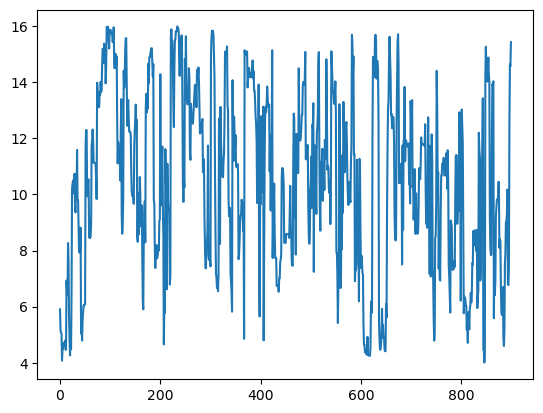

In [32]:
a=scaler_pars.inverse_transform(samples_nuts )
plt.plot(a[100:,1])

In [23]:
b=pd.DataFrame(a)
a

In [24]:
b.to_csv("C:/Users/345578/Desktop/NewML/MCMC_runs/Run6_24_25_2.csv" )

950


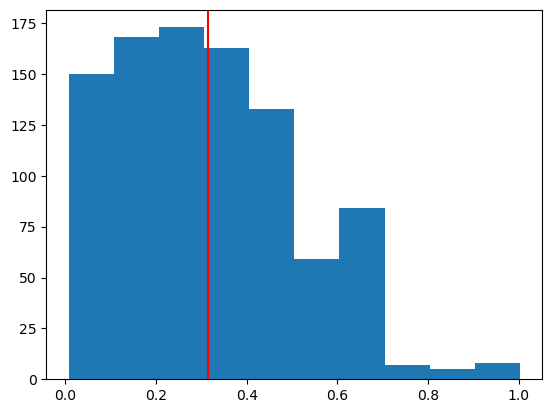

In [31]:
n=5

sample_size = int(len(a) * (95 / 100))
indices = np.random.choice(len(a), size=sample_size, replace=False)
print(len(a[indices,n]))
plt.hist(a[indices,n])
plt.axvline(a[:,n].mean(),c="red")